<a href="https://colab.research.google.com/github/IT21280238/Emotion-Recognition-Intensity-Prediction-/blob/Arousal-Valance-Prediction/Affect_Regression_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Model Training for Expression 3**

In [1]:
import pandas as pd
import os

In [2]:
df_3= pd.read_csv("/content/expression_3.csv")

In [3]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14090 entries, 0 to 14089
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Image       14090 non-null  object 
 1   Arousal     14090 non-null  float64
 2   Valence     14090 non-null  float64
 3   Expression  14090 non-null  int64  
 4   Index       14090 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 550.5+ KB


In [4]:
df_3_val= pd.read_csv("/content/expression_val_3.csv")

In [5]:
df_3_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Image       500 non-null    object 
 1   Arousal     500 non-null    float64
 2   Valence     500 non-null    float64
 3   Expression  500 non-null    int64  
 4   Index       500 non-null    object 
dtypes: float64(2), int64(1), object(2)
memory usage: 19.7+ KB


In [7]:
df_3.head()

,Image,Arousal,Valence,Expression,Index
0,/content/preprocessed_images/167246.npy,0.668564,0.163906,3,"[7.9975000000000005, 73.56846715328467, 6.5625..."
1,/content/preprocessed_images/262951.npy,0.774293,0.527487,3,"[-13.39607843137255, 112.29793103448276, -9.13..."
2,/content/preprocessed_images/209613.npy,0.622051,0.359288,3,"[4.219178082191781, 73.42222222222222, 4.21917..."
3,/content/preprocessed_images/17924.npy,0.487405,0.138026,3,"[16.669148514851486, 79.4401462522852, 14.7839..."
4,/content/preprocessed_images/393516.npy,0.643631,0.232288,3,"[17.848128342245985, 92.85306532663316, 23.178..."


In [8]:
df_3_val.head()

,Image,Arousal,Valence,Expression,Index
0,/content/val_set/val_set/images/2978.jpg,0.890223,-0.084281,3,"[21.76118518518518, 92.22283636363636, 22.4248..."
1,/content/val_set/val_set/images/1967.jpg,0.869153,-0.042141,3,"[33.62064516129031, 86.32848758465012, 33.6825..."
2,/content/val_set/val_set/images/3870.jpg,0.600077,0.217770,3,"[37.211999999999996, 86.44069364161851, 39.367..."
3,/content/val_set/val_set/images/1745.jpg,0.800031,0.133976,3,"[7.515974842767296, 82.93582554517133, 10.1504..."
4,/content/val_set/val_set/images/4865.jpg,0.508130,0.275842,3,"[10.420666666666666, 76.99779527559055, 12.628..."


In [9]:
# Drop unnecessary columns
df_3 = df_3.drop(columns=["Expression", "Index"])

# Save the cleaned dataset
df_3.to_csv("df_0.csv", index=False)

# Display the first few rows of the cleaned dataset
print(df_3.head())


                                     Image   Arousal   Valence
0  /content/preprocessed_images/167246.npy  0.668564  0.163906
1  /content/preprocessed_images/262951.npy  0.774293  0.527487
2  /content/preprocessed_images/209613.npy  0.622051  0.359288
3   /content/preprocessed_images/17924.npy  0.487405  0.138026
4  /content/preprocessed_images/393516.npy  0.643631  0.232288


In [10]:
# Drop unnecessary columns
df_3_val = df_3_val.drop(columns=["Expression", "Index"])

# Save the cleaned dataset
df_3_val.to_csv("df_0_val.csv", index=False)

# Display the first few rows of the cleaned dataset
print(df_3_val.head())


                                      Image   Arousal   Valence
0  /content/val_set/val_set/images/2978.jpg  0.890223 -0.084281
1  /content/val_set/val_set/images/1967.jpg  0.869153 -0.042141
2  /content/val_set/val_set/images/3870.jpg  0.600077  0.217770
3  /content/val_set/val_set/images/1745.jpg  0.800031  0.133976
4  /content/val_set/val_set/images/4865.jpg  0.508130  0.275842


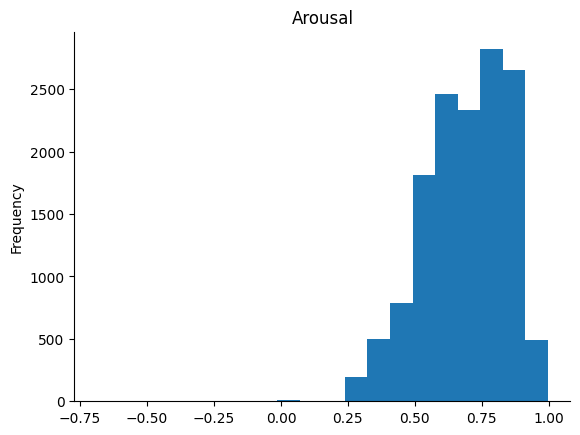

In [11]:
from matplotlib import pyplot as plt
df_3['Arousal'].plot(kind='hist', bins=20, title='Arousal')
plt.gca().spines[['top', 'right',]].set_visible(False)

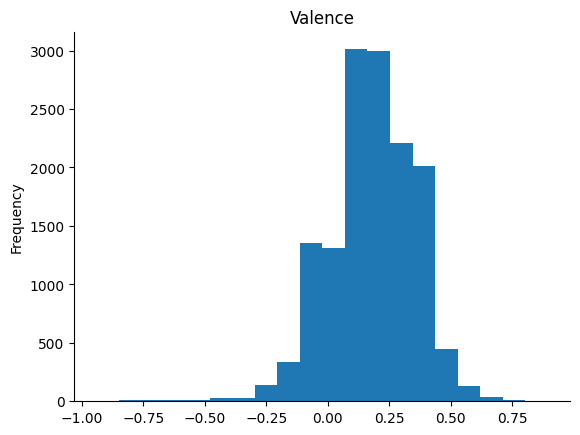

In [12]:
df_3['Valence'].plot(kind='hist', bins=20, title='Valence')
plt.gca().spines[['top', 'right',]].set_visible(False)

# Regression -

In [ ]:
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input

def define_mtl_va_model(input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)

    # Shared Feature Extraction
    x = Conv2D(64, (7,7), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)

    x = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3,3), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.3)(x)

    x = Conv2D(256, (1,1), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)

    x = Conv2D(256, (3,3), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3,3), activation='relu', kernel_initializer='he_uniform',
               padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(0.4)(x)

    x = Flatten()(x)

    # Task-Specific Layers
    valence_branch = Dense(256, activation='relu', kernel_initializer='he_uniform',
                           kernel_regularizer=regularizers.l2(0.001))(x)
    valence_branch = BatchNormalization()(valence_branch)
    valence_branch = Dropout(0.5)(valence_branch)
    valence_output = Dense(1, activation='linear', name='valence')(valence_branch)

    arousal_branch = Dense(256, activation='relu', kernel_initializer='he_uniform',
                           kernel_regularizer=regularizers.l2(0.001))(x)
    arousal_branch = BatchNormalization()(arousal_branch)
    arousal_branch = Dropout(0.5)(arousal_branch)
    arousal_output = Dense(1, activation='linear', name='arousal')(arousal_branch)

    # Define Model with Two Outputs
    model = Model(inputs=inputs, outputs=[valence_output, arousal_output])

    return model


In [ ]:
model = define_mtl_va_model(input_shape=(224, 224, 3))

In [ ]:
import cv2
import numpy as np
import os

# Convert JPG images to NPY format
for img_path in df_3_val["Image"]:
    img = cv2.imread(img_path)  # Read image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    img = cv2.resize(img, (224, 224))  # Resize
    img = img.astype(np.float32) / 255.0  # Normalize

    npy_path = img_path.replace(".jpg", ".npy")  # Save as .npy
    np.save(npy_path, img)

    # Update dataset path to the new .npy file
    df_3_val["Image"] = df_3_val["Image"].replace(img_path, npy_path)

# Save the updated CSV file
df_3_val.to_csv("df_1_val_updated.csv", index=False)


In [ ]:
df_3_val.head()

In [ ]:
import tensorflow as tf

def load_and_preprocess(img_path, valence, arousal):
    def _load_npy(path):
        path = path.numpy().decode("utf-8")  # Convert Tensor to string
        img = np.load(path)  # Load .npy image
        img = cv2.resize(img, (224, 224))  # Resize

        # Ensure image has 3 channels
        if len(img.shape) == 2:  # Grayscale image
            img = np.stack([img] * 3, axis=-1)  # Convert to 3-channel format
        elif img.shape[-1] != 3:  # Incorrect channel count
            img = img[:, :, :3]  # Keep only first 3 channels if needed

        img = img / 255.0  # Normalize
        return img.astype(np.float32)

    img = tf.py_function(func=_load_npy, inp=[img_path], Tout=tf.float32)

    # 🚀 Explicitly set shape to avoid TensorFlow shape errors
    img.set_shape((224, 224, 3))

    return img, {"valence": tf.reshape(valence, [1]), "arousal": tf.reshape(arousal, [1])}


In [ ]:
# Convert DataFrame columns to a list
image_paths = df_3["Image"].tolist()
valence_values = df_3["Valence"].tolist()
arousal_values = df_3["Arousal"].tolist()

In [ ]:
# Create Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((image_paths, valence_values, arousal_values))
train_dataset = train_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(8).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Extract validation image paths and labels
val_image_paths = df_3_val["Image"].values  # Paths to validation .npy files
val_valence_labels = df_3_val["Valence"].values.astype(np.float32)
val_arousal_labels = df_3_val["Arousal"].values.astype(np.float32)

In [ ]:
val_dataset = tf.data.Dataset.from_tensor_slices((val_image_paths, val_valence_labels, val_arousal_labels))
val_dataset = val_dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(8).prefetch(tf.data.AUTOTUNE)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss={'valence': 'mse', 'arousal': 'mse'},
              metrics={'valence': 'mae', 'arousal': 'mae'})

In [ ]:
history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)